# Python String Methods: `title()` vs. `capitalize()`

**Topics covered:** word-boundary detection · apostrophes and hyphens · Unicode behaviour · choosing the right method for names, titles, and headings

Python provides two built-in string methods that both produce "nicely capitalised" text, yet they operate on fundamentally different units of text and frequently diverge on real-world strings. This notebook works through every documented edge case with **live, runnable code**, so the differences are observed directly rather than just described.

**Roadmap**

1. The core definitions
2. Side-by-side comparison on simple text
3. Edge cases: apostrophes, hyphens, and digits
4. Unicode behaviour
5. A complete decision flowchart
6. Practical recommendations


In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.facecolor"] = "white"


## 1. The Core Definitions

* **`str.capitalize()`** operates on the **entire string** as a single unit: it uppercases the first character and lowercases every other character, regardless of how many words the string contains.
* **`str.title()`** operates on **every word boundary** independently: it uppercases the first letter of *each* word and lowercases the rest of that word's letters.

The practical consequence is immediate: `capitalize()` only ever produces one capital letter (at position 0); `title()` can produce many, one per detected word boundary.

In [2]:
sample = "the quick brown fox jumps over the lazy dog"
print("Original:  ", repr(sample))
print("capitalize:", repr(sample.capitalize()))
print("title:     ", repr(sample.title()))


Original:   'the quick brown fox jumps over the lazy dog'
capitalize: 'The quick brown fox jumps over the lazy dog'
title:      'The Quick Brown Fox Jumps Over The Lazy Dog'


## 2. Side-by-Side Comparison on Simple Text

On a clean, simple sentence the difference is exactly what the definitions predict: `capitalize()` produces one capital letter at the very start; `title()` produces one capital letter at the start of every word.

In [3]:
examples = [
    "hello world",
    "PYTHON programming language",
    "the lord of the rings",
    "mr. smith went to washington",
]

for text in examples:
    print(f"{'Original:':12s} {text!r}")
    print(f"{'capitalize:':12s} {text.capitalize()!r}")
    print(f"{'title:':12s} {text.title()!r}")
    print()


Original:    'hello world'
capitalize:  'Hello world'
title:       'Hello World'

Original:    'PYTHON programming language'
capitalize:  'Python programming language'
title:       'Python Programming Language'

Original:    'the lord of the rings'
capitalize:  'The lord of the rings'
title:       'The Lord Of The Rings'

Original:    'mr. smith went to washington'
capitalize:  'Mr. smith went to washington'
title:       'Mr. Smith Went To Washington'



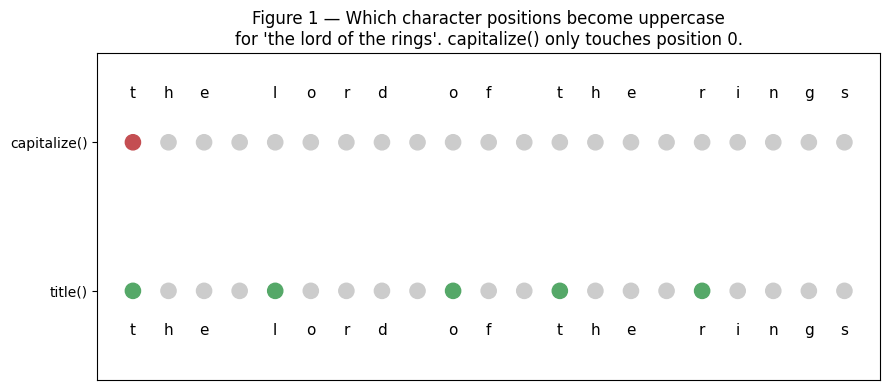

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
demo_text = "the lord of the rings"
positions = np.arange(len(demo_text))

cap_result = demo_text.capitalize()
title_result = demo_text.title()

cap_is_upper = [c.isupper() for c in cap_result]
title_is_upper = [c.isupper() for c in title_result]

ax.scatter(positions, [1]*len(demo_text), c=["#C44E52" if u else "#CCCCCC" for u in cap_is_upper], s=120)
ax.scatter(positions, [0]*len(demo_text), c=["#55A868" if u else "#CCCCCC" for u in title_is_upper], s=120)
for i, ch in enumerate(demo_text):
    ax.text(i, 1.3, ch, ha="center", fontsize=11)
    ax.text(i, -0.3, ch, ha="center", fontsize=11)

ax.set_yticks([0, 1])
ax.set_yticklabels(["title()", "capitalize()"])
ax.set_xticks([])
ax.set_xlim(-1, len(demo_text))
ax.set_ylim(-0.6, 1.6)
ax.set_title(f"Figure 1 — Which character positions become uppercase\nfor '{demo_text}'. capitalize() only touches position 0.")
plt.tight_layout()
plt.show()


## 3. Edge Cases: Apostrophes, Hyphens, and Digits

`title()` determines word boundaries using non-alphabetic characters, which produces some well-known, frequently-surprising results: an apostrophe inside a contraction is treated as a word boundary, so the letter immediately after it gets capitalised too.

In [5]:
edge_cases = [
    "they're going to o'brien's house",
    "well-known co-author",
    "it's a 3-day event",
    "tom's ph.d. thesis",
]

for text in edge_cases:
    print(f"{'Original:':12s} {text!r}")
    print(f"{'capitalize:':12s} {text.capitalize()!r}")
    print(f"{'title:':12s} {text.title()!r}  <-- watch the apostrophes / hyphens")
    print()


Original:    "they're going to o'brien's house"
capitalize:  "They're going to o'brien's house"
title:       "They'Re Going To O'Brien'S House"  <-- watch the apostrophes / hyphens

Original:    'well-known co-author'
capitalize:  'Well-known co-author'
title:       'Well-Known Co-Author'  <-- watch the apostrophes / hyphens

Original:    "it's a 3-day event"
capitalize:  "It's a 3-day event"
title:       "It'S A 3-Day Event"  <-- watch the apostrophes / hyphens

Original:    "tom's ph.d. thesis"
capitalize:  "Tom's ph.d. thesis"
title:       "Tom'S Ph.D. Thesis"  <-- watch the apostrophes / hyphens



Notice `"o'brien's"` becomes `"O'Brien'S"` under `title()` — the apostrophe before the final "s" is treated as a word boundary, capitalising a letter that should stay lowercase. This single example is the most common reason `title()` is the wrong tool for real names: it has no linguistic understanding of contractions or possessives, only a mechanical rule about non-alphabetic boundary characters.

**The standard fix** for this apostrophe problem is a small contraction-aware helper: split each word on its apostrophes, and only re-capitalise a fragment if it is *not* one of the small set of common English contraction/possessive suffixes (`'s`, `'t`, `'re`, `'ve`, `'ll`, `'d`, `'m`). This correctly leaves a possessive `'s` lowercase while still capitalising genuine second name-parts such as the "Brien" in "O'Brien.

In [6]:
import re

CONTRACTION_SUFFIXES = {"s", "t", "re", "ve", "ll", "d", "m"}

def smart_title(text):
    def cap_word(word):
        parts = word.split("'")
        capitalised = [parts[0].capitalize()]
        for part in parts[1:]:
            # Keep known contraction/possessive suffixes lowercase ("'s", "'re", "'t", ...);
            # capitalise anything else, since it is most likely a second name part (e.g. "Brien").
            capitalised.append(part.lower() if part.lower() in CONTRACTION_SUFFIXES else part.capitalize())
        return "'".join(capitalised)

    return re.sub(r"[A-Za-z']+", lambda m: cap_word(m.group(0)), text)

problem_text = "they're going to o'brien's house"
print("title():      ", repr(problem_text.title()))
print("smart_title(): ", repr(smart_title(problem_text)))


title():       "They'Re Going To O'Brien'S House"
smart_title():  "They're Going To O'Brien's House"


## 4. Unicode Behaviour

Both methods are Unicode-aware out of the box and correctly handle accented characters and non-Latin scripts, without requiring any special configuration.

In [7]:
unicode_examples = ["café münchen", "naïve résumé", "ångström façade"]

for text in unicode_examples:
    print(f"{'Original:':12s} {text!r}")
    print(f"{'capitalize:':12s} {text.capitalize()!r}")
    print(f"{'title:':12s} {text.title()!r}")
    print()


Original:    'café münchen'
capitalize:  'Café münchen'
title:       'Café München'

Original:    'naïve résumé'
capitalize:  'Naïve résumé'
title:       'Naïve Résumé'

Original:    'ångström façade'
capitalize:  'Ångström façade'
title:       'Ångström Façade'



## 5. A Complete Decision Flowchart

The figure below condenses the entire decision process from the source paper into a single diagram.

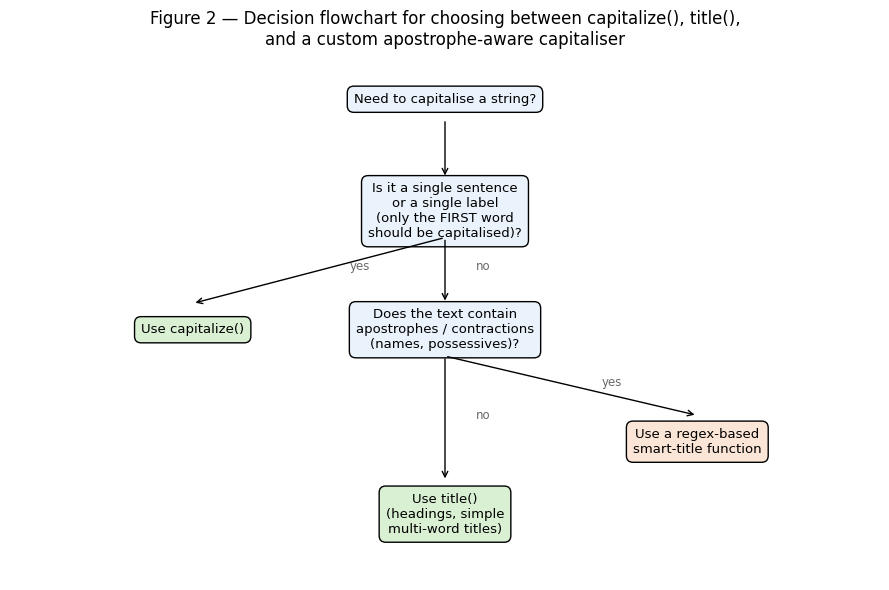

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.axis("off")

def box(xy, text, color="#EAF2FB"):
    ax.annotate(text, xy, ha="center", va="center", fontsize=9.5,
                bbox=dict(boxstyle="round,pad=0.5", fc=color, ec="black"))

def arrow(xy1, xy2, label=""):
    ax.annotate("", xy2, xy1, arrowprops=dict(arrowstyle="->", color="black"))
    if label:
        mx, my = (xy1[0]+xy2[0])/2, (xy1[1]+xy2[1])/2
        ax.text(mx + 0.35, my, label, fontsize=8.5, color="dimgray")

box((5, 9.3), "Need to capitalise a string?")
box((5, 7.6), "Is it a single sentence\nor a single label\n(only the FIRST word\nshould be capitalised)?")
box((2.1, 5.8), "Use capitalize()", color="#D9F0D3")
box((5, 5.8), "Does the text contain\napostrophes / contractions\n(names, possessives)?")
box((7.9, 4.1), "Use a regex-based\nsmart-title function", color="#FBE5D6")
box((5, 3.0), "Use title()\n(headings, simple\nmulti-word titles)", color="#D9F0D3")

arrow((5, 9.0), (5, 8.1))
arrow((5, 7.2), (2.1, 6.2), "yes")
arrow((5, 7.2), (5, 6.2), "no")
arrow((5, 5.4), (7.9, 4.5), "yes")
arrow((5, 5.4), (5, 3.5), "no")

ax.set_xlim(0, 10)
ax.set_ylim(2, 10)
ax.set_title("Figure 2 — Decision flowchart for choosing between capitalize(), title(),\nand a custom apostrophe-aware capitaliser")
plt.tight_layout()
plt.show()


## 6. Practical Recommendations

| Use case | Recommended method | Reason |
|---|---|---|
| Sentence-style headings ("Submit form") | `capitalize()` | Only the first word should be capitalised |
| Simple multi-word titles ("Chapter Two") | `title()` | Each content word should be capitalised |
| Names containing apostrophes ("O'Brien") | Custom regex-based function | `title()` incorrectly capitalises after the apostrophe |
| Hyphenated names ("Smith-Jones") | `title()` usually works correctly | Hyphens are treated as boundaries, capitalising both parts as intended |
| Acronyms inside titles ("NASA Mission Update") | Neither — apply `title()` then restore acronyms | Both methods lowercase letters that follow the first one, including in acronyms |
| User-submitted form data | `capitalize()` or `strip().capitalize()` | Predictable, single capitalisation point; avoid surprising multi-word effects |

**One more important pitfall to check explicitly:** both methods lowercase the *rest* of every affected word, which silently destroys intentional internal capitalisation — `"iPhone".title()` becomes `"Iphone"`, not `"IPhone"`. Always verify behaviour on brand names, acronyms, and proper nouns before using either method in production text-processing code.

In [9]:
brand_examples = ["iPhone 15 pro", "eBay listing", "McDonald's menu"]
for text in brand_examples:
    print(f"{text!r:30s} -> title(): {text.title()!r}")


'iPhone 15 pro'                -> title(): 'Iphone 15 Pro'
'eBay listing'                 -> title(): 'Ebay Listing'
"McDonald's menu"              -> title(): "Mcdonald'S Menu"


## 7. Conclusion

`capitalize()` and `title()` solve two genuinely different problems: `capitalize()` capitalises a string as a single unit (one capital letter, always at position 0); `title()` capitalises every detected word independently. Both are Unicode-aware, but neither has any linguistic awareness of contractions, possessives, or brand-name capitalisation conventions — exactly the gap that a small regex-based helper function is designed to fill. The right choice in practice is rarely "always use `title()` for anything multi-word" — it is to check, explicitly, whether the input is expected to contain apostrophes, hyphens, acronyms, or stylised brand names, and fall back to a custom function whenever it might.

## References

1. Python Software Foundation. *`str.capitalize()` and `str.title()`.* Python 3 Standard Library Reference.
2. Python Software Foundation. *Unicode HOWTO.*
3. Real Python. *Strings and Character Data in Python.*
4. Python Enhancement Proposals. *PEP 3137 — Immutable Bytes and Mutable Buffer.*